In [3]:
import glob

latent_files = glob.glob("D:/LatentFeatures/*_train/*.npy")

print("Total latent files:", len(latent_files))

Total latent files: 5042


In [4]:
import numpy as np

def is_leaf_patch(patch):

    # use one spectral band to detect leaf area
    band = patch[:,:,50]

    # normalize
    band = band / band.max()

    bright_pixels = np.sum(band > 0.2)

    total_pixels = band.size

    ratio = bright_pixels / total_pixels

    # keep patch if majority is leaf
    return ratio > 0.6

In [5]:
filtered_latents = []
filtered_files = []

for f in latent_files:

    patch_file = f.replace("D:/LatentFeatures","E:/project/WeedCube_Patches/train")
    patch_file = patch_file.replace("canola_train","canola")
    patch_file = patch_file.replace("soybean_train","soybean")
    patch_file = patch_file.replace("waterhemp_train","waterhemp")
    patch_file = patch_file.replace("_latent.npy",".npy")

    patch = np.load(patch_file)

    if is_leaf_patch(patch):

        latent = np.load(f)

        filtered_latents.append(latent)
        filtered_files.append(f)

print("Remaining patches:", len(filtered_latents))

Remaining patches: 3219


In [6]:
X_filtered = np.array(filtered_latents).T

print("Filtered matrix shape:", X_filtered.shape)

Filtered matrix shape: (30, 3219)


In [7]:
import skfuzzy as fuzz

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_filtered,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000
)

labels_filtered = np.argmax(u, axis=0)

print("New FPC:", fpc)

New FPC: 0.7377550711733101


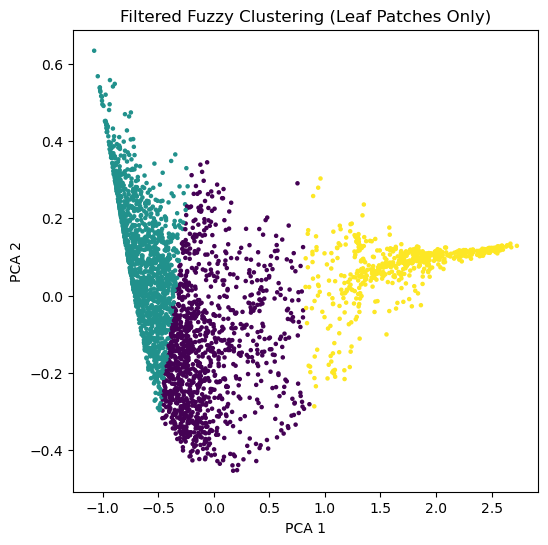

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X2 = pca.fit_transform(X_filtered.T)

plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=labels_filtered, cmap='viridis', s=5)

plt.title("Filtered Fuzzy Clustering (Leaf Patches Only)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

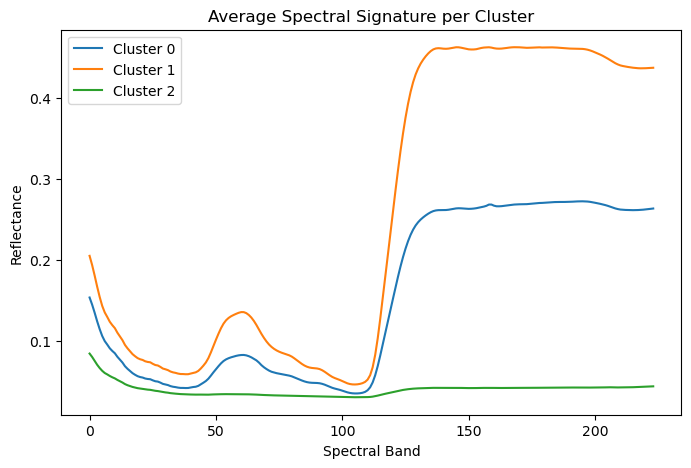

In [9]:
import numpy as np
import matplotlib.pyplot as plt

clusters = 3

spectra = {0:[], 1:[], 2:[]}

for i,f in enumerate(filtered_files):

    patch_file = f.replace("D:/LatentFeatures","E:/project/WeedCube_Patches/train")
    patch_file = patch_file.replace("canola_train","canola")
    patch_file = patch_file.replace("soybean_train","soybean")
    patch_file = patch_file.replace("waterhemp_train","waterhemp")
    patch_file = patch_file.replace("_latent.npy",".npy")

    patch = np.load(patch_file)

    spectrum = np.mean(patch, axis=(0,1))

    spectra[labels_filtered[i]].append(spectrum)

plt.figure(figsize=(8,5))

for c in range(clusters):

    avg_curve = np.mean(spectra[c], axis=0)

    plt.plot(avg_curve, label=f"Cluster {c}")

plt.xlabel("Spectral Band")
plt.ylabel("Reflectance")
plt.title("Average Spectral Signature per Cluster")

plt.legend()

plt.show()

In [10]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

cluster_range = range(2,7)

fpcs = []

for c in cluster_range:

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_filtered,
        c=c,
        m=2,
        error=0.005,
        maxiter=1000
    )

    fpcs.append(fpc)

    print("Clusters:",c,"FPC:",fpc)

Clusters: 2 FPC: 0.9133970145567007
Clusters: 3 FPC: 0.7377550725869566
Clusters: 4 FPC: 0.7025756149381012
Clusters: 5 FPC: 0.6433747138351011
Clusters: 6 FPC: 0.5963069483577831
